# Wavelet para señales de ECG
---
En este notebook detallaremos, como es que aplicamos las transformadas de wavelet para las señales que adquirimos en el laboratoiro 4

## 1) Preparación de Datos (Carga y Filtrado Básico)
---

En esta primera etapa, realizaremos la preparación fundamental de nuestros datos. Las acciones son dos:

1.  **Carga de Datos:** Leeremos todos los archivos `_converted.txt` desde la carpeta `SeñalesECG`. Este paso nos da acceso a las señales crudas en formato numérico.
2.  **Filtrado Pasa-Banda (Butterworth):** Aplicaremos un filtro pasa-banda a cada señal cargada.

**¿Por qué un filtro básico primero?** Las señales de ECG crudas casi siempre tienen dos tipos de ruido principales:
*   **Deriva de la Línea de Base:** Una ondulación lenta causada por la respiración o el movimiento del electrodo. Nuestro filtro la elimina con el corte de baja frecuencia (0.5 Hz).
*   **Ruido de Alta Frecuencia:** Interferencia de la red eléctrica o ruido electrónico. Nuestro filtro lo atenúa con el corte de alta frecuencia (40 Hz).


La salida de este primer filtro será nuestra señal de "partida" antes del análisis wavelet.

Librerías importadas.
Se encontraron 4 archivos de ECG para analizar:

Filtrado Pasa-Banda aplicado a todas las señales.


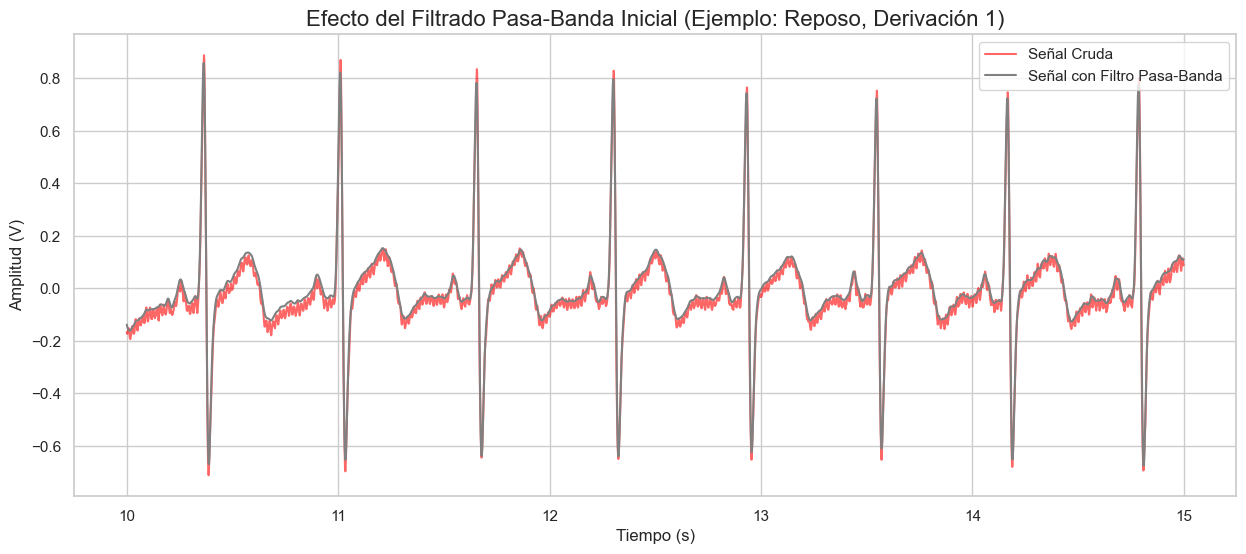

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set(style="whitegrid")
print("Librerías importadas.")

# --- 1. Carga de Datos ---
carpeta_datos = "Señales_ECG"
fs = 1000  # Frecuencia de muestreo en Hz
datos_cargados = {}

if not os.path.isdir(carpeta_datos):
    print(f"Error: La carpeta '{carpeta_datos}' no fue encontrada.")
else:
    archivos_ecg = sorted([f for f in os.listdir(carpeta_datos) if f.endswith("_converted.txt")])
    print(f"Se encontraron {len(archivos_ecg)} archivos de ECG para analizar:")
    for archivo in archivos_ecg:
        ruta_completa = os.path.join(carpeta_datos, archivo)
        try:
            with open(ruta_completa, 'r') as f:
                for i, linea in enumerate(f):
                    if "EndOfHeader" in linea:
                        skiprows = i + 1
                        break
                else: skiprows = 0
            df = pd.read_csv(ruta_completa, sep="\t", skiprows=skiprows, header=None)
            nombres_cols = ["nSeq", "I1", "I2", "01", "02", "A2", "A5"]
            df.columns = nombres_cols[:len(df.columns)]
            senal = df["A2"].values
            tiempo = np.arange(len(senal)) / fs
            datos_cargados[archivo] = {'tiempo': tiempo, 'senal_v_cruda': senal}
        except Exception as e:
            print(f" -> Error al cargar el archivo '{archivo}': {e}")

# --- 2. Filtrado Pasa-Banda (Butterworth) ---
from scipy.signal import butter, filtfilt

def filtrar_ecg_pasabanda(senal, low_cut=0.5, high_cut=40, fs=1000):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, senal)

for archivo, data in datos_cargados.items():
    datos_cargados[archivo]['senal_filtrada'] = filtrar_ecg_pasabanda(data['senal_v_cruda'])

print("\nFiltrado Pasa-Banda aplicado a todas las señales.")

# --- Visualización del Efecto del Primer Filtro ---
# Seleccionamos un archivo de ejemplo para visualizar
archivo_ejemplo = next((f for f in datos_cargados if "_reposo_" in f and "Derivacion_1" in f), None)
if archivo_ejemplo:
    tiempo_ej = datos_cargados[archivo_ejemplo]['tiempo']
    senal_cruda_ej = datos_cargados[archivo_ejemplo]['senal_v_cruda']
    senal_filtrada_ej = datos_cargados[archivo_ejemplo]['senal_filtrada']
    
    # Seleccionamos un segmento para ver el detalle
    idx = (tiempo_ej >= 10) & (tiempo_ej < 15)
    
    plt.figure(figsize=(15, 6))
    plt.plot(tiempo_ej[idx], senal_cruda_ej[idx], color='red', alpha=0.6, label='Señal Cruda')
    plt.plot(tiempo_ej[idx], senal_filtrada_ej[idx], color='gray', label='Señal con Filtro Pasa-Banda')
    plt.title('Efecto del Filtrado Pasa-Banda Inicial (Ejemplo: Reposo, Derivación 1)', fontsize=16)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (V)')
    plt.legend()
    plt.show()

### 2. Definición de Denoising Wavelet
---

Aquí definimos nuestra herramienta de filtrado avanzado. Esta celda contiene la función `filtrar_con_wavelet`, que encapsula la lógica de **denoising**. Para poder usar más adelante

El proceso dentro de la función es el siguiente:
1.  **Descomposición:** Se descompone la señal en múltiples "capas" o niveles de frecuencia usando la Transformada Wavelet (`wavedec`). Elegimos la wavelet `'sym8'` porque su forma es similar a la del complejo QRS, lo que la hace muy efectiva para el ECG.
    **Acá como comentario, cuando cambiamos a `wavelet='db4'`, con 4 niveles sale mucho mas fiel a la señal original**

2.  **Umbral Adaptativo:** **Este es el paso que corrige el error anterior.** En lugar de un solo umbral para todo, calculamos un umbral específico para *cada nivel de detalle*. Esto nos permite ser agresivos con el ruido en las capas de muy alta frecuencia, y mucho más cuidadosos en las capas donde vive la información del QRS.
3.  **Reconstrucción:** Se reconstruye la señal a partir de los coeficientes ya limpios (`waverec`), resultando en una señal "denoised" de la misma longitud que la original.

In [38]:
def filtrar_con_wavelet(senal, wavelet='db4', level=4):
    """
    Filtra (denoise) una señal usando la Transformada Wavelet con un umbral adaptativo por nivel.
    """
    # 1. Descomponer la señal en coeficientes wavelet
    coeffs = pywt.wavedec(senal, wavelet, mode='per', level=level)
    
    # 2. Calcular y aplicar un umbral para CADA nivel de detalle
    coeffs_umbral = [coeffs[0]] # Mantenemos los coeficientes de aproximación intactos
    
    for i in range(1, len(coeffs)):
        # Calcular el umbral universal de VisuShrink para este nivel específico
        sigma = np.median(np.abs(coeffs[i])) / 0.6745
        umbral = sigma * np.sqrt(2 * np.log(len(senal)))
        
        # Aplicar el umbral "suave" a los coeficientes de este nivel
        coeffs_umbral.append(pywt.threshold(coeffs[i], umbral, mode='soft'))
    
    # 3. Reconstruir la señal a partir de los coeficientes umbralizados
    senal_denoised = pywt.waverec(coeffs_umbral, wavelet, mode='per')
    
    # Asegurar que la longitud coincida con la señal original
    return senal_denoised[:len(senal)]

print("Función 'filtrar_con_wavelet' definida correctamente.")

Función 'filtrar_con_wavelet' definida correctamente.


### 3. Organización de Archivos para el Análisis

Antes de poder aplicar nuestro filtro y comparar, necesitamos organizar los archivos para filtrar, los estamos guardando en diccionadios anidados agrupados por condición como `Condición` ("Reposo", "Actividad Física") y por `Derivación` ("Derivacion_1", "Derivacion_2").

Con este diccionario ordenado, podemos aplicar las funciones de wavelet a los archivos de manera iterativa y ordenada

In [18]:
archivos_agrupados = {
    'Reposo': {},
    'Actividad Física': {}
}

for archivo in datos_cargados.keys():
    if "_reposo_" in archivo:
        condicion = 'Reposo'
    elif "actividad_fisica" in archivo:
        condicion = 'Actividad Física'
    else:
        continue

    if "Derivacion_1" in archivo or "derivacion_1" in archivo:
        derivacion = 'Derivacion_1'
    elif "Derivacion_2" in archivo or "derivacion_2" in archivo:
        derivacion = 'Derivacion_2'
    else:
        continue
        
    archivos_agrupados[condicion][derivacion] = archivo

print("Archivos organizados para el análisis comparativo:")
import json
print(json.dumps(archivos_agrupados, indent=2))

Archivos organizados para el análisis comparativo:
{
  "Reposo": {
    "Derivacion_1": "Derivacion_1_reposo_2025-09-10_11-47-35_converted.txt",
    "Derivacion_2": "Derivacion_2_reposo_2025-09-10_12-02-50_converted.txt"
  },
  "Actividad F\u00edsica": {
    "Derivacion_1": "derivacion_1_actividad_fisica_2025-09-10_12-20-25_converted.txt",
    "Derivacion_2": "derivacion_2_actividad_fisica_2025-09-10_12-24-06_converted.txt"
  }
}


### 4. Aplicación y Visualización Comparativa Final
---

Ahora aquí aplicamos nuestro nuevo filtro wavelet y visualizamos los resultados.

Iteraremos a través de la estructura organizada que creamos en la celda anterior. Para cada una de las 4 combinaciones (ej. Reposo - Derivación 1), haremos lo siguiente:
1.  Tomaremos la señal que ya pasó por el filtro pasa-banda.
2.  Le aplicaremos nuestra nueva función `filtrar_con_wavelet`.
3.  Generaremos un **gráfico comparativo final** que mostrará la señal antes y después del filtro wavelet.

Los gráficos esperados deberían mostrar claramente cómo el ruido fino y muscular se atenúa significativamente, mientras que la forma esencial del complejo QRS se preserva perfectamente. Se espera que el efecto sea mucho más dramático en las señales de "Actividad Física".

--- Procesando Condición: Reposo ---
Aplicando filtro wavelet a: Derivacion_1


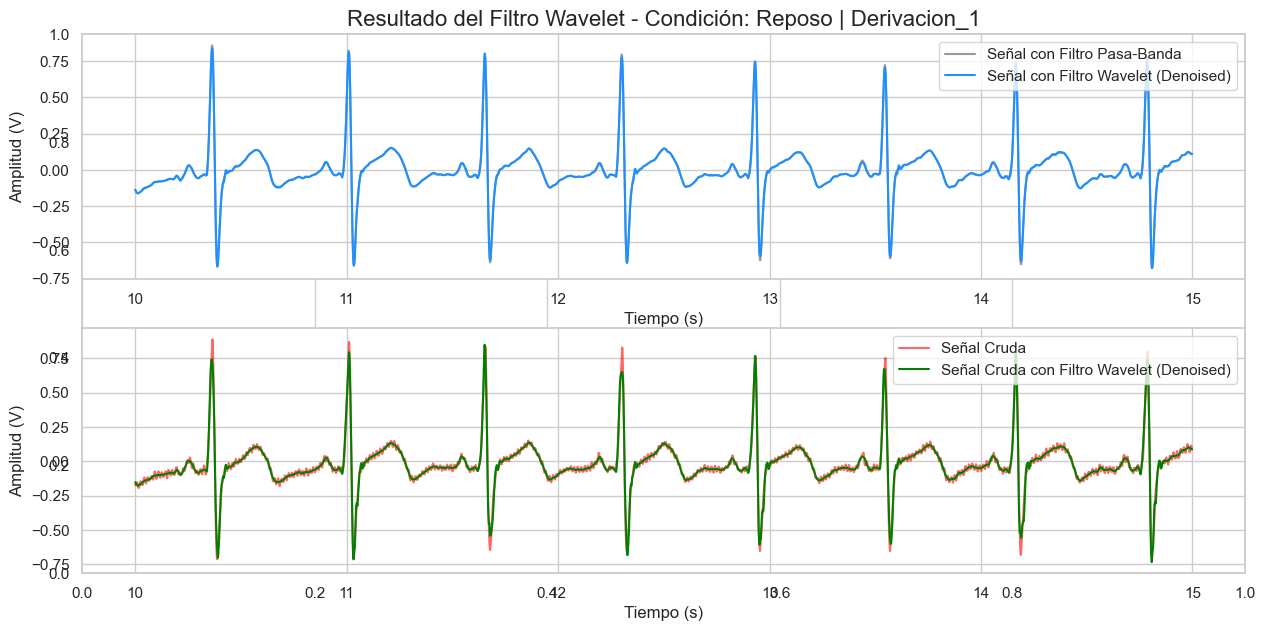

Aplicando filtro wavelet a: Derivacion_2


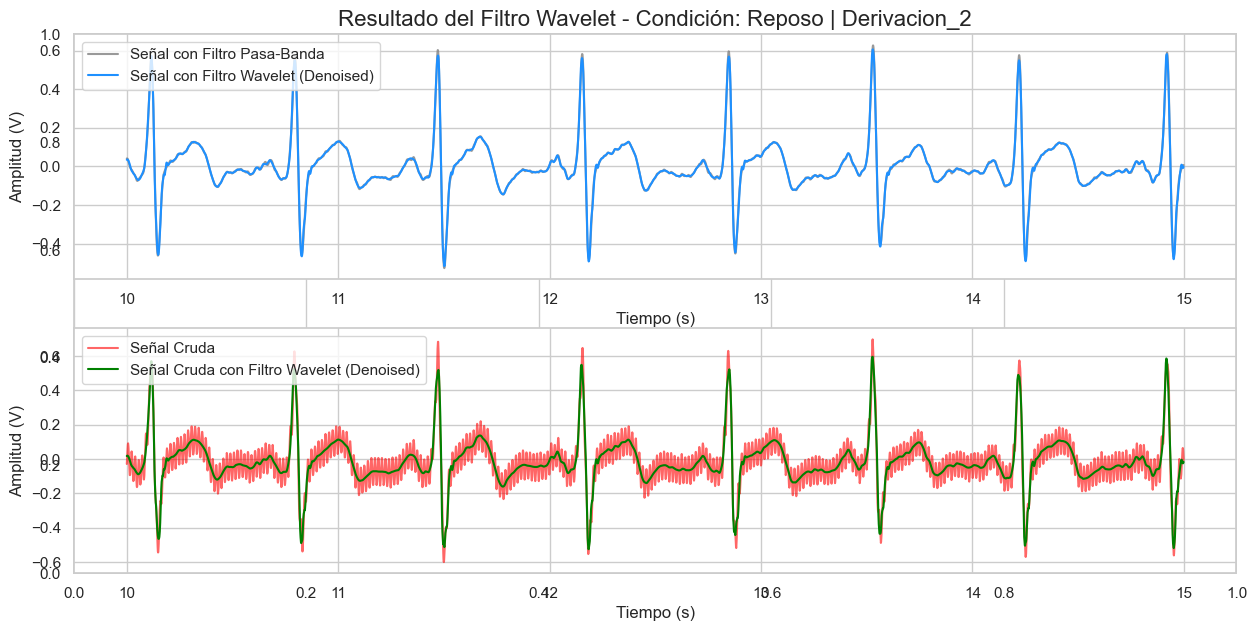

--- Procesando Condición: Actividad Física ---
Aplicando filtro wavelet a: Derivacion_1


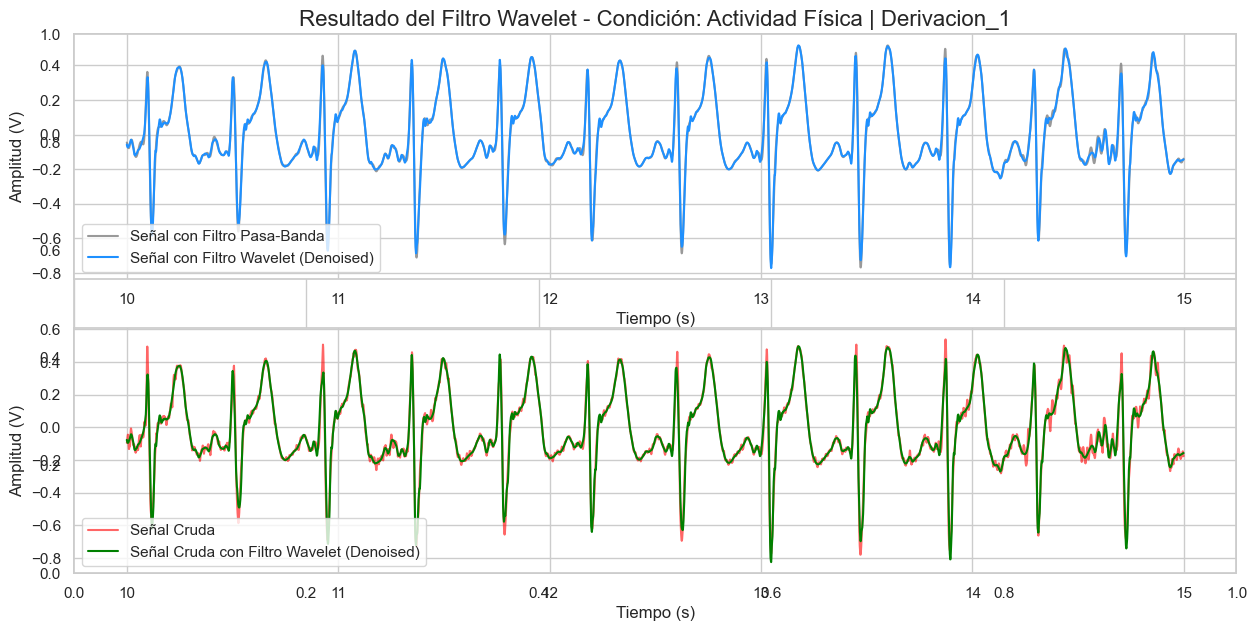

Aplicando filtro wavelet a: Derivacion_2


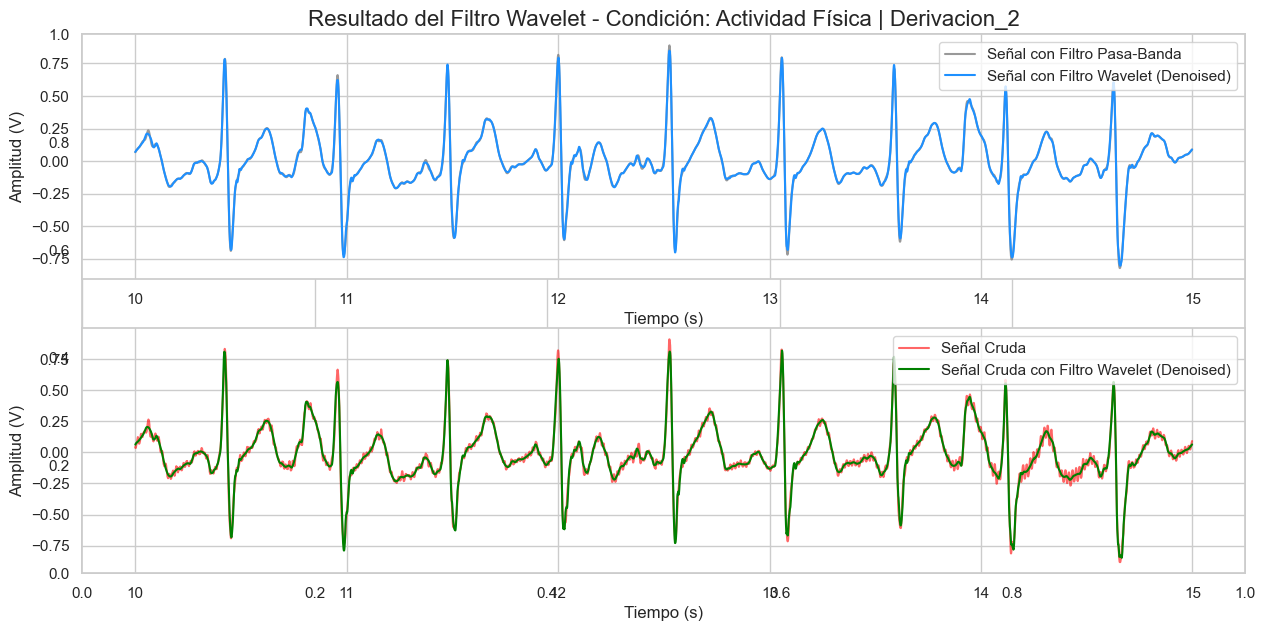

In [39]:
# Iterar sobre cada condición y derivación para aplicar el filtro y graficar
for condicion, derivaciones in archivos_agrupados.items():
    print(f"--- Procesando Condición: {condicion} ---")
    for derivacion, archivo in derivaciones.items():
        if archivo is None:
            print(f"No se encontró archivo para {condicion}, {derivacion}. Saltando.")
            continue
            
        print(f"Aplicando filtro wavelet a: {derivacion}")
        
        # Obtener la señal pre-filtrada
        tiempo = datos_cargados[archivo]['tiempo']
        senal_prefiltrada = datos_cargados[archivo]['senal_filtrada']

        # Para comparar, también obtenemos la señal cruda
        senal_cruda = datos_cargados[archivo]['senal_v_cruda']
        
        # Aplicar el filtro wavelet a ambas comparaciones
        senal_denoised = filtrar_con_wavelet(senal_prefiltrada)
        senal_denoised_cruda = filtrar_con_wavelet(senal_cruda)
        
        # Guardar el resultado para futuros análisis
        datos_cargados[archivo]['senal_denoised'] = senal_denoised
        datos_cargados[archivo]['senal_denoised_cruda'] = senal_denoised_cruda
        
        # --- Visualización Comparativa ---
        idx = (tiempo >= 10) & (tiempo < 15) # Segmento de 5 segundos
        
        plt.figure(figsize=(15, 7))

        plt.title(f'Resultado del Filtro Wavelet - Condición: {condicion} | {derivacion}', fontsize=16)    

        plt.subplot(2, 1, 1)
        plt.plot(tiempo[idx], senal_prefiltrada[idx], color='gray', alpha=0.8, label='Señal con Filtro Pasa-Banda')
        plt.plot(tiempo[idx], senal_denoised[idx], color='dodgerblue', linewidth=1.5, label='Señal con Filtro Wavelet (Denoised)')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud (V)')
        plt.legend()
        plt.grid(True)


        plt.subplot(2, 1, 2)
        plt.plot(tiempo[idx], senal_cruda[idx], color='red', alpha=0.6, label='Señal Cruda')
        plt.plot(tiempo[idx], senal_denoised_cruda[idx], color='green', linewidth=1.5, label='Señal Cruda con Filtro Wavelet (Denoised)')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud (V)')
        plt.legend()
        plt.grid(True)

        plt.show()

        